# Total vehicule-kilometers travelled

### The objective of this notebook is to estimate the total distance travelled by year and region on main roads in the province of Quebec.

In the first section, permanent sensors data and estimated DJMAs from the MTMD are used to estimate the DJMA for missing years on sections with at least one available DJMA.
The second section estimates DJMAs on sections for which there is no available data by matching sections without data with sections having available DJMAs.
In the third section, total vehicules-kilometers travelled per year are calculated. Their evolution per region is shown. 

In [5]:
# import packages
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import geopandas as gpd

import importlib
import MyFunctionsOpenQuebec

# Force a reload of the module
importlib.reload(MyFunctionsOpenQuebec)

from MyFunctionsOpenQuebec import read_filtered_excel, aggregate_filtered_data

In [7]:
# Specify the folder path
folder_path = 'debit_circulation_quebec'  
subfolders = next(os.walk(folder_path))[1]

All subfolders have a length of 10 characters (Route: 5, Tronçon: 2, Section: 3)

In [10]:
def create_complete_df (sheet):
    # sheet is the name of the excel sheet the data comes from (string). Possible values are 'histo', 'fact84' and 'horaire'
    # the folder_path and subfolders variables are outside the scope of this function
    data_voie = {}
    
    for voie in [11, 12, 13]:
        data_voie[voie] = aggregate_filtered_data(folder_path, subfolders, 'VOIE', [voie], sheet).drop_duplicates(subset=['num_sectn_', 'ANNEE'], keep='first')
        colnames = []
        
        for colname in list (data_voie[voie].columns):
            if colname not in ['SECTN','num_sectn_', 'ANNEE', 'VOIE']:
                colnames.append(colname + '_' + str(voie))
            else:
                colnames.append (colname)
                
        data_voie[voie].columns = colnames
        data_voie[voie] = data_voie[voie].drop(columns = ['VOIE', 'SECTN'])
        df = data_voie[voie]

    # Merging the dataframes from different directions
    merged_directions = pd.merge(data_voie[11], data_voie[12], on=['num_sectn_', 'ANNEE'], how='outer')
    merged_directions = pd.merge(merged_directions, data_voie[13], on=['num_sectn_', 'ANNEE'], how='outer')
    merged_directions = merged_directions.replace({None:np.nan})
    merged_directions = merged_directions.replace({0:np.nan})
    merged_directions['DJMA_11_12'] = merged_directions['DJMA_11'].add(merged_directions['DJMA_12'], fill_value = 0)

    return merged_directions

In [12]:
def create_total_df (merged_directions):

    # Create dataframe with aggreagated data on both directions on desired indicators
    # The highest value between (11 + 12) and 13 is kept, this decision is arbitrary
    
    indicator = 'DJMA'
    indicator_tot = indicator + '_tot'
    merged_directions['DJMA_tot'] = merged_directions[[indicator+'_11_12', indicator+'_13']].max(axis=1) # to keep highest value
    merged_directions['num_sectn_'] = merged_directions['num_sectn_'].astype(str)

    keep_cols = ['num_sectn_', 'ANNEE'] + [indicator_tot]
    return merged_directions[keep_cols]

### Section 1. Estimation of missing DJMAs for sections having at least one available DJMA

In [14]:
merged_directions = create_complete_df('histo')

Error reading file: debit_circulation_quebec\0001518007\0001518007_2021.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0002514302\0002514302_2020.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0004014400\0004014400_2020.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0013810001\0013810001_2020.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0001518007\0001518007_2021.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0002514302\0002514302_2020.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0004014400\0004014400_2020.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0013810001\0013810001_2020.xlsx
Worksheet named 'histo' not found
Error reading file: debit_circulation_quebec\0001518007\0001518007_2021.xlsx
Worksheet named 'histo' not found
E

In [16]:
merged_directions.to_csv('complete_df_num_sectn_.csv', index = False)

In [643]:
df_tot = create_total_df(merged_directions)
df_tot.columns = ['num_sectn_', 'ANNEE', 'DJMA']
df_tot.head()

,num_sectn_,ANNEE,DJMA
0,0001012500,2011,78000.0
1,0001012500,2012,77000.0
2,0001012500,2013,79000.0
3,0001012500,2014,79000.0
4,0001012500,2015,80000.0


In [645]:
gdf = gpd.read_file(r"cir_v_geo_sectn_trafc_locls\cir_v_geo_sectn_trafc_locls.shp") 
gdf['code'] = [rtss[-4] for rtss in gdf['rtss_fin']]
gdf ['R'] = [rts[0:5] for rts in gdf['num_sectn_']]
gdf ['RT'] = [rts[0:7] for rts in gdf['num_sectn_']]

It makes no sense to consider the flow for code 'H' (recreational or tourist facility, such as rest areas, lookouts, scenic spots, etc.). The only codes kept for VKT analysis will be '0' (main road), '3' (interchange and ramp) and 'V' (acces road)

In [649]:
gdf = gdf[gdf['code'].isin(['0', '3', 'V'])]

In [653]:
# Create dictionary mapping col -> year
recent_year = int(gdf.loc[0,'djma_ann_1'])
years_cols = {col: str(recent_year - i) for i, col in enumerate(col_djma)}

# Rename columns and keep only relevant ones
col_djma = ['val_djma_' + str(i) for i in range(1,10)] + ['val_djma10']
gdf_long = gdf[['num_sectn_'] + col_djma].copy()
gdf_long = gdf_long.rename(columns= years_cols)

# Transform to long format
year_columns = list(years_cols.values())
gdf_long = gdf_long.melt(id_vars='num_sectn_', value_vars=year_columns,
                          var_name='ANNEE', value_name='DJMA')
gdf_long['ANNEE'] = gdf_long['ANNEE'].astype(int)

# Keep only rows with values
gdf_long = gdf_long[gdf_long['DJMA'].notna()]

# add DJMA_tot column in df_tot───────────────────────────────────────────────
df_tot['DJMA_tot'] = df_tot['DJMA']

# ── Step 3: outer merge ───────────────────────────────────────────────────────
gdf_long_merged = pd.merge(gdf_long, df_tot[['num_sectn_', 'ANNEE', 'DJMA_tot']],
                            on=['num_sectn_', 'ANNEE'], how='outer')

# ── Step 4: DJMA_ref and fill_source ─────────────────────────────────────────
gdf_long_merged['DJMA_ref'] = gdf_long_merged['DJMA_tot'].combine_first(gdf_long_merged['DJMA'])
gdf_long_merged['fill_source'] = np.where(gdf_long_merged['DJMA_tot'].notna(), 'permanent', 'MTMD')
df_long_merged = gdf_long_merged[['num_sectn_', 'ANNEE', 'DJMA_ref', 'fill_source']]

In [659]:
gdf = gdf[['num_sectn_', 'R', 'RT', 'code', 'geometry']]
gdf_region = gpd.read_file(r"regions\regio_s.shp")
gdf = gdf.to_crs(gdf_region.crs)

gdf_region_renamed = gdf_region[['RES_NM_REG', 'geometry']].rename(columns={'RES_NM_REG': 'region'})
gdf_clipped = gpd.overlay(gdf, gdf_region_renamed, how='intersection', keep_geom_type=True)
gdf_clipped.head()

,num_sectn_,R,RT,code,region,geometry
0,9936004000,99360,9936004,0,Gaspésie–Îles-de-la-Madeleine,"LINESTRING (-64.40134 48.51331, -64.40062 48.5..."
1,0013884000,00138,0013884,0,Côte-Nord,"MULTILINESTRING ((-68.25541 49.20372, -68.2554..."
2,0013889600,00138,0013889,0,Côte-Nord,"LINESTRING (-66.39663 50.24366, -66.3965 50.24..."
3,8481507000,84815,8481507,0,Estrie,"LINESTRING (-70.9099 45.59215, -70.90991 45.59..."
4,0025310000,00253,0025310,0,Estrie,"LINESTRING (-71.49915 45.06978, -71.49899 45.0..."


In [661]:
def find_max_year(df):
    
    # Returns latest year suitable for analysis (maximum year in the dataframe or (maximum year -1) if there is not enough data for the maximum year)

    indicator = 'DJMA_ref'
    max_year = max(df['ANNEE'])
    last_year = max_year-1

    mask_max = (df['ANNEE'] == max_year) & (df[indicator].notna())
    mask_last = (df['ANNEE'] == last_year) & (df[indicator].notna())
        
    sections_max = set(df[mask_max]['num_sectn_'])
    sections_last = set(df[mask_last]['num_sectn_'])
    
    if len(sections_max) < 0.5*len (sections_last):
        max_year = last_year

    return max_year

In [669]:
# create all combinations of num_sectn_ and years
year_max = find_max_year(df_long_merged)
year_0 = 2011 # can be modified
all_sections = gdf['num_sectn_'].unique()
all_years = range(year_0, year_max + 1)
complete_index = pd.MultiIndex.from_product([all_sections, all_years], names=['num_sectn_', 'ANNEE'])
complete_df = pd.DataFrame(index=complete_index).reset_index()

#merge  to fill in existing data
complete_df_merged = pd.merge(complete_df, df_long_merged, on=['num_sectn_', 'ANNEE'], how='left')

# fill in static columns (R, RT, code, geometry) that are the same for all years of a section
static_cols = ['num_sectn_', 'R', 'RT', 'code', 'region', 'geometry']
static_gdf = gdf_clipped[static_cols].drop_duplicates(subset='num_sectn_') # simplification for estimating missing djma: a section is only linked to 1 region
df_djma = pd.merge(complete_df_merged, static_gdf, on='num_sectn_', how='left')
gdf_djma = gpd.GeoDataFrame(df_djma, crs=gdf.crs)
gdf_djma['DJMA_ref'] = pd.to_numeric(gdf_djma['DJMA_ref'])

In [671]:
sectn_with_values = gdf_djma[gdf_djma['DJMA_ref'].notna()]['num_sectn_'].unique().tolist()
gdf_djma_filling = gdf_djma[gdf_djma['num_sectn_'].isin(sectn_with_values)]

In [500]:
def add_djma_interpolation(df, pandemic_year=2020):
    """
    Estimates missing DJMA values at the section level using linear interpolation
    between two known values. No extrapolation outside the known data range.
    A slope is invalid if it overlaps the pandemic year (2020), unless 2020 is 
    the first year used to calculate the slope.
    
    """
    df = df.copy().sort_values(['num_sectn_', 'ANNEE'])
    
    sections = df['num_sectn_'].unique()
    
    for section in sections:
        mask_section = df['num_sectn_'] == section
        df_section = df[mask_section][['ANNEE', 'DJMA_ref']].copy()
        
        # Known years (non-NA DJMA)
        known = df_section[df_section['DJMA_ref'].notna()].sort_values('ANNEE')
        known_years = known['ANNEE'].tolist()
        
        if len(known_years) < 2:
            continue  # need at least 2 known values to interpolate
        
        # Missing years within the known range (no extrapolation)
        missing_years = df_section[
            (df_section['DJMA_ref'].isna()) &
            (df_section['ANNEE'] >= known_years[0]) &
            (df_section['ANNEE'] <= known_years[-1])
        ]['ANNEE'].tolist()
        
        for year in missing_years:
            # Find the closest known year before and after
            prev_years = [y for y in known_years if y < year]
            next_years = [y for y in known_years if y > year]
            
            if not prev_years or not next_years:
                continue
            
            year_prev = max(prev_years)
            year_next = min(next_years)
            
            # Check if slope overlaps pandemic year
            # Invalid if pandemic_year is strictly between year_prev and year_next
            overlaps_pandemic = (year_prev < pandemic_year <= year_next)
            
            if overlaps_pandemic:
                continue  # skip this estimate
            
            # Linear interpolation
            djma_prev = known[known['ANNEE'] == year_prev]['DJMA_ref'].values[0]
            djma_next = known[known['ANNEE'] == year_next]['DJMA_ref'].values[0]
            
            slope = (djma_next - djma_prev) / (year_next - year_prev)
            estimate = djma_prev + slope * (year - year_prev)
            
            df.loc[mask_section & (df['ANNEE'] == year), 'DJMA_interpolated'] = estimate
    
    return df

In [675]:
gdf_djma_filling = add_djma_interpolation(gdf_djma_filling)

In [677]:
print('Number of DJMAs estimated with the interpolation method:')
gdf_djma_filling['DJMA_interpolated'].notna().sum()

Number of DJMAs estimated with the interpolation method:


1165

In [506]:
def fill_djma_missing(df, pandemic_year=2020):
    """
    Estimates missing DJMA values at the section level using slopes computed
    at the RT, R, and region levels. Iterates until no more values can be filled.
    Steps 1-6 are applied independently for each section with at least one missing DJMA.
    
    Parameters:
    -----------
    df : DataFrame with columns 'num_sectn_', 'ANNEE', 'DJMA', 'DJMA_interpolated', 'RT', 'R', 'region'
    pandemic_year : year to avoid overlapping with (default: 2020)
    
    Returns:
    --------
    df : DataFrame with new column 'DJMA_filled'
    stats : dict with counts of estimates per aggregation level
    """
    df = df.copy().sort_values(['num_sectn_', 'ANNEE'])
    stats = {'RT': 0, 'R': 0, 'region': 0}

    # ── Helper: check if a year range overlaps the pandemic ──────────────────
    def overlaps_pandemic(year_start, year_end):
        if year_start == pandemic_year:
            return False
        if year_start == pandemic_year - 1 and year_end == pandemic_year:
            return False
        return year_start < pandemic_year <= year_end

    # ── Helper: compute slope dataframe for a given agg_var ──────────────────
    def compute_slopes(df_slopes, agg_var):
        # Mean across sections for each (agg_var, ANNEE)
        df_agg_var = (df_slopes.groupby([agg_var, 'ANNEE'])['rel_chg']
                               .mean()
                               .reset_index()
                               .rename(columns={'rel_chg': f'{agg_var}_slope'}))
    
        df_agg_var = df_agg_var.sort_values([agg_var, 'ANNEE'])
    
        # Compute slope_inv at the aggregated level (one row per agg_var/ANNEE)
        slope_next = df_agg_var.groupby(agg_var)[f'{agg_var}_slope'].shift(-1)
        df_agg_var[f'{agg_var}_slope_inv'] = 1 / slope_next.where(slope_next != 0)
    
        # Merge both slope and slope_inv back to section level
        df_merged = pd.merge(df_slopes, df_agg_var, on=[agg_var, 'ANNEE'], how='left')
    
        return df_merged

    # ── Helper: one pass for a given section and agg_var ─────────────────────
    def fill_one_pass_section(df_working, section, agg_var):
        """
        For a given section, evaluate ALL unknown years simultaneously.
        For each unknown year, only use the immediately adjacent year (year-1 or year+1).
        Returns updated df and number of new estimates.
        """
        slope_col     = f'{agg_var}_slope'
        slope_col_inv = f'{agg_var}_slope_inv'
        n_new = 0

        df_sec   = df_working[df_working['num_sectn_'] == section].sort_values('ANNEE')
        unknown  = df_sec[df_sec['DJMA_working'].isna()]

        for idx, row in unknown.iterrows():
            year = row['ANNEE']

            est_prev = np.nan
            est_next = np.nan

            # Check immediately adjacent previous year (year - 1)
            prev_row = df_working[
                (df_working['num_sectn_'] == section) & (df_working['ANNEE'] == year - 1)
            ]
            if not prev_row.empty and pd.notna(prev_row['DJMA_working'].values[0]):
                slope_val = df_working.loc[idx, slope_col]
                if pd.notna(slope_val):
                    est_prev = prev_row['DJMA_working'].values[0] * slope_val

            # Check immediately adjacent next year (year + 1)
            next_row = df_working[
                (df_working['num_sectn_'] == section) & (df_working['ANNEE'] == year + 1)
            ]
            if not next_row.empty and pd.notna(next_row['DJMA_working'].values[0]):
                slope_val_inv = df_working.loc[idx, slope_col_inv]
                if pd.notna(slope_val_inv):
                    est_next = next_row['DJMA_working'].values[0] * slope_val_inv

            if pd.notna(est_prev) or pd.notna(est_next):
                estimate = np.nanmean([v for v in [est_prev, est_next] if pd.notna(v)])
                df_working.loc[idx, 'DJMA_working'] = estimate
                df_working.loc[idx, 'DJMA_filled']  = estimate
                df_working.loc[idx, 'fill_source']  = agg_var
                stats[agg_var] += 1
                n_new += 1

        return df_working, n_new

    # ── Helper: iterate fill for all sections until convergence ──────────────
    def iterate_fill(df_working, agg_var):
        sections_with_missing = df_working[df_working['DJMA_working'].isna()]['num_sectn_'].unique()
        for section in sections_with_missing:
            while True:
                df_working, n_new = fill_one_pass_section(df_working, section, agg_var)
                if n_new == 0:
                    break
        return df_working

    # ── Main: initialize working DJMA column ─────────────────────────────────
    df['DJMA_working'] = df['DJMA_ref'].combine_first(df['DJMA_interpolated'])
    df['DJMA_filled']  = df['DJMA_working'].copy()
    agg_vars = ['RT', 'R', 'region']

    #Compute slopes at the section level
    df_known = df[df['DJMA_working'].notna()].copy()
    df_known = df_known.drop_duplicates(subset=['num_sectn_', 'ANNEE'])
    df_known = df_known.sort_values(['num_sectn_', 'ANNEE'])

    sections = df_known['num_sectn_'].unique()
    df['rel_chg'] = np.nan

    for section in sections:
        df_section = df_known[df_known['num_sectn_'] == section].reset_index(drop=True)
        if len(df_section) == 1:
            continue

        for i in range(1, len(df_section)):
            djma_prev = df_section.loc[i-1, 'DJMA_working']
            djma_curr = df_section.loc[i,   'DJMA_working']
            year_prev = df_section.loc[i-1, 'ANNEE']
            year_curr = df_section.loc[i,   'ANNEE']
        
            if djma_prev == 0 or pd.isna(djma_prev):
                continue
        
            if overlaps_pandemic(year_prev, year_curr):
                rel_chg = [np.nan] * (year_curr - year_prev)
            else:
                annual_chg = (djma_curr - djma_prev) / (year_curr - year_prev)
                rel_chg = [(j * annual_chg + djma_prev) / ((j-1) * annual_chg + djma_prev)
                           for j in range(1, (year_curr - year_prev) + 1)]
        
            for year, chg in zip(range(year_prev + 1, year_curr + 1), rel_chg):
                df.loc[
                    (df['num_sectn_'] == section) & (df['ANNEE'] == year),
                    'rel_chg'
                ] = chg

    # ── Compute slopes per agg_var once and add to df ────────────────────────────────────
    for agg_var in agg_vars:
        df = compute_slopes(df, agg_var)
    df = df.drop(columns=['rel_chg'], errors='ignore')

    # ── Step 1-2: fill with RT, iterate per section until convergence ─────────
    print(f"Before filling: {df['DJMA_working'].isna().sum()} missing")
    df = iterate_fill(df, 'RT')
    print(f"After RT filling: {df['DJMA_working'].isna().sum()} missing")

    # ── Step 3-4: fill with R, re-running RT before each R iteration ──────────
    sections_with_missing = df[df['DJMA_working'].isna()]['num_sectn_'].unique()
    for section in sections_with_missing:
        while True:
            df, n_new_R = fill_one_pass_section(df, section, 'R')
            if n_new_R == 0:
                break
            # Re-run RT for this section after each R estimate
            while True:
                df, n_new_RT = fill_one_pass_section(df, section, 'RT')
                if n_new_RT == 0:
                    break
    print(f"After R filling: {df['DJMA_working'].isna().sum()} missing")

    # ── Step 5-6: fill with region, re-running RT+R before each iteration ─────
    sections_with_missing = df[df['DJMA_working'].isna()]['num_sectn_'].unique()
    for section in sections_with_missing:
        while True:
            df, n_new_region = fill_one_pass_section(df, section, 'region')
            if n_new_region == 0:
                break
            # Re-run RT then R for this section after each region estimate
            while True:
                df, n_new_RT = fill_one_pass_section(df, section, 'RT')
                if n_new_RT == 0:
                    break
            while True:
                df, n_new_R = fill_one_pass_section(df, section, 'R')
                if n_new_R == 0:
                    break
                while True:
                    df, n_new_RT = fill_one_pass_section(df, section, 'RT')
                    if n_new_RT == 0:
                        break
    print(f"After region filling: {df['DJMA_working'].isna().sum()} missing")

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\nDJMA estimates by aggregation level:")
    for agg_var, count in stats.items():
        print(f"  {agg_var}: {count} estimates")
    print(f"  Still missing: {df['DJMA_working'].isna().sum()}")

    # Drop intermediate slope columns

    return df, stats

In [508]:
gdf_years_filled, stats = fill_djma_missing(gdf_djma_filling) ## takes a long time to run

Before filling: 26152 missing
After RT filling: 22216 missing
After R filling: 10846 missing
After region filling: 112 missing

DJMA estimates by aggregation level:
  RT: 3973 estimates
  R: 11337 estimates
  region: 10730 estimates
  Still missing: 112


Main limit of the fill_djma_missing and add_djma_interpolation functions: They do not take into account road closures. The fill djma_missing function doesn't take new roads contruction into account (djma of a new section can be estimated for years when the section didn't even exist)

### Section 2. Estimating DJMAs for sections whitout any avaible DJMA value

In [514]:
# Only keep sections with estimated values for all years
still_missing_sectn = gdf_years_filled[gdf_years_filled['DJMA_working'].isna()]['num_sectn_'].unique()
gdf_years_filled = gdf_years_filled[~gdf_years_filled['num_sectn_'].isin(still_missing_sectn)]

In [516]:
sections_all_values = gdf_years_filled['num_sectn_'].unique()
gdf_no_values = gdf_djma[~gdf_djma['num_sectn_'].isin(sections_all_values)]
gdf_no_values = gdf_no_values[gdf_no_values['code'].isin(['0', 'V'])] # 0: main road (voie principale), V: service road (voie de service)
# It doesn't make sense to try to estimate DJMAs on other types of roads (ex: ramp)

In [539]:
def complete_gdf_djma(gdf_no_values, gdf_years_filled, gdf_clipped, buffer_distance):
    crs_metric = 'EPSG:32198'
    gdf_no_values    = gdf_no_values.to_crs(crs_metric)
    gdf_years_filled = gdf_years_filled.to_crs(crs_metric)

    stats = {'adjacent': 0, 'RT': 0, 'R': 0}

    # ── Pivot gdf_years_filled to wide format for easier averaging ────────────
    year_columns = sorted(gdf_years_filled['ANNEE'].unique())

    gdf_years_wide = gdf_years_filled.pivot_table(
        index=['num_sectn_', 'R', 'RT', 'code', 'geometry'],
        columns='ANNEE',
        values='DJMA_working'
    ).reset_index()
    gdf_years_wide.columns.name = None
    gdf_years_wide = gpd.GeoDataFrame(gdf_years_wide, geometry='geometry', crs=crs_metric)

    # ── Prepare sections with no data ─────────────────────────────────────────
    gdf_section_na = (gdf_no_values[['num_sectn_', 'R', 'RT', 'code', 'geometry']]
                      .drop_duplicates(subset='num_sectn_')
                      .copy())
    gdf_section_na['fill_source'] = None
    print(f"Initially {gdf_section_na['fill_source'].isna().sum()} empty sections")
    # ── Step 1: iterative adjacent filling ───────────────────────────────────
    gdf_known = gdf_years_wide.copy()

    while True:
        n_filled = 0
        still_empty = gdf_section_na[gdf_section_na['fill_source'].isna()]

        for idx, row in still_empty.iterrows():
            buffered_geom = row['geometry'].buffer(buffer_distance)
            adjacent = gdf_known[
                (gdf_known['R']    == row['R']) &
                (gdf_known['code'] == row['code']) &
                (gdf_known['geometry'].intersects(buffered_geom))
            ]
            if adjacent.empty:
                continue

            means = adjacent[year_columns].mean()
            gdf_section_na.loc[idx, year_columns] = means.values
            gdf_section_na.loc[idx, 'fill_source'] = 'adjacent'
            stats['adjacent'] += 1
            n_filled += 1

            gdf_known = pd.concat([gdf_known, gdf_section_na.loc[[idx]]], ignore_index=True)
            gdf_known = gpd.GeoDataFrame(gdf_known, geometry='geometry', crs=crs_metric)

        if n_filled == 0:
            break

    print(f"After adjacent filling: {gdf_section_na['fill_source'].isna().sum()} sections still empty")

    # ── Step 2: fill with RT mean ─────────────────────────────────────────────
    rt_code_means = gdf_years_wide.groupby(['RT', 'code'])[year_columns].mean()

    still_empty = gdf_section_na[gdf_section_na['fill_source'].isna()]
    for idx, row in still_empty.iterrows():
        key = (row['RT'], row['code'])
        if key in rt_code_means.index:
            gdf_section_na.loc[idx, year_columns] = rt_code_means.loc[key].values
            gdf_section_na.loc[idx, 'fill_source'] = 'R'
            stats['RT'] += 1

    print(f"After RT filling: {gdf_section_na['fill_source'].isna().sum()} sections still empty")

    # ── Step 3: fill with R + code mean ──────────────────────────────────────
    r_code_means = gdf_years_wide.groupby(['R', 'code'])[year_columns].mean()

    still_empty = gdf_section_na[gdf_section_na['fill_source'].isna()]
    for idx, row in still_empty.iterrows():
        key = (row['R'], row['code'])
        if key in r_code_means.index:
            gdf_section_na.loc[idx, year_columns] = r_code_means.loc[key].values
            gdf_section_na.loc[idx, 'fill_source'] = 'R'
            stats['R'] += 1

    print(f"After R filling: {gdf_section_na['fill_source'].isna().sum()} sections still empty")

    # ── Convert to long format ────────────────────────────────────────────────
    id_cols = ['num_sectn_', 'R', 'RT', 'code', 'geometry', 'fill_source']
    gdf_long = gdf_section_na.melt(
        id_vars=id_cols,
        value_vars=year_columns,
        var_name='ANNEE',
        value_name='DJMA_working'
    )
    gdf_long['ANNEE'] = gdf_long['ANNEE'].astype(int)
    gdf_long = gpd.GeoDataFrame(gdf_long, geometry='geometry', crs=crs_metric)
    gdf_long = gdf_long.sort_values(['num_sectn_', 'ANNEE']).reset_index(drop=True)

    
    # Create final dataframe
    df_long = gdf_long[['num_sectn_', 'R', 'RT', 'code', 'ANNEE', 'DJMA_working', 'fill_source']]
    df_years_filled = gdf_years_filled[['num_sectn_', 'R', 'RT', 'code', 'ANNEE', 'DJMA_working', 'fill_source']].copy()
    df_final = pd.concat([df_years_filled, df_long], ignore_index=True)
    gdf_final = pd.merge(gdf_clipped[['num_sectn_', 'region', 'geometry']].to_crs(crs_metric), df_final, on='num_sectn_', how='left')
    gdf_final = gdf_final[gdf_final['DJMA_working'].notna()]
    gdf_final = gpd.GeoDataFrame(gdf_final, geometry='geometry', crs=crs_metric)
    # ── Summary ───────────────────────────────────────────────────────────────
    print("\nSections filled by method:")
    for method, count in stats.items():
        print(f"  {method}: {count} sections")

    return gdf_final

In [541]:
gdf_complete_djma = complete_gdf_djma(gdf_no_values, gdf_years_filled, gdf_clipped, buffer_distance = 30) 

Initially 1078 empty sections
After adjacent filling: 501 sections still empty
After RT filling: 487 sections still empty
After R filling: 404 sections still empty

Sections filled by method:
  adjacent: 577 sections
  RT: 14 sections
  R: 83 sections


Main limit of the complete gdf_djma_function: it doesn't take intersections and ramps into account (the flow can vary substantialy between two sections of the same road).

### Section 3. VKT calculation and analysis per region

In [544]:
gdf_complete_djma.drop_duplicates(subset = ['num_sectn_', 'region']).geometry.geom_type.value_counts()

LineString         4083
MultiLineString    1511
Name: count, dtype: int64

In [546]:
gdf_unique = gdf_complete_djma.drop_duplicates(subset=['num_sectn_', 'region'])
multilines = gdf_unique[gdf_unique.geometry.geom_type == 'MultiLineString']
pd.Series(multilines.geometry.apply(lambda x: len(x.geoms))).value_counts().sort_index()

geometry
2     1130
3      278
4       24
5       52
6       14
7        4
8        3
9        1
10       2
11       1
12       1
19       1
Name: count, dtype: int64

Most sections are a simple line, and a fair share are double lines (probably two way sections). Some sections are divided into more lines, but there are not a lot, so it is considered that a wrong estimation of their length will not affect the results too much.

In [549]:
def create_df_length(gdf_complete_djma):
    gdf_unique = gdf_complete_djma.drop_duplicates(subset=['num_sectn_', 'region']).copy()
    gdf_unique['len'] = gdf_unique.geometry.apply(
        lambda geometry: np.mean([x.length for x in geometry.geoms]) 
        if geometry.geom_type == 'MultiLineString' # mean is not perfect, but a good estimate for two ways sections
        else geometry.length
    )
    df_len = pd.merge(gdf_complete_djma, gdf_unique[['num_sectn_', 'region', 'len']], on=['num_sectn_', 'region'], how='left')
    return df_len

In [551]:
df_final = create_df_length(gdf_complete_djma)
df_final.head()

,num_sectn_,region,geometry,R,RT,code,ANNEE,DJMA_working,fill_source,len
0,9936004000,Gaspésie–Îles-de-la-Madeleine,"LINESTRING (301363.599 510173.454, 301414.531 ...",99360,9936004,0,2011.0,609.415225,region,4834.828361
1,9936004000,Gaspésie–Îles-de-la-Madeleine,"LINESTRING (301363.599 510173.454, 301414.531 ...",99360,9936004,0,2012.0,596.575771,region,4834.828361
2,9936004000,Gaspésie–Îles-de-la-Madeleine,"LINESTRING (301363.599 510173.454, 301414.531 ...",99360,9936004,0,2013.0,560.590984,region,4834.828361
3,9936004000,Gaspésie–Îles-de-la-Madeleine,"LINESTRING (301363.599 510173.454, 301414.531 ...",99360,9936004,0,2014.0,551.995418,region,4834.828361
4,9936004000,Gaspésie–Îles-de-la-Madeleine,"LINESTRING (301363.599 510173.454, 301414.531 ...",99360,9936004,0,2015.0,580.000000,MTMD,4834.828361


In [553]:
df_final.to_csv('df_final_vkt.csv', index = False)

In [555]:
print(f"The final dataframe has {df_final['num_sectn_'].nunique()} sections, all of which have djma values across all analyzed years")

The final dataframe has 5472 sections, all of which have djma values across all analyzed years


In [631]:
# Data source for VKT calculation (number of sections per data source per region), to keep in mind when analyzing the subsequent graphs
data_fill_source = pd.merge(df_long_merged[df_long_merged['DJMA_ref'].notna()].drop_duplicates(subset=['num_sectn_']), gdf_clipped[['num_sectn_', 'region']])
freq_fill_final = (df_final.drop_duplicates(subset=['num_sectn_', 'region'])
                      .groupby(['region'])
                      .size()
                      .reset_index())

freq_table = (data_fill_source.drop_duplicates(subset=['num_sectn_', 'region'])
                      .groupby(['region', 'fill_source'])
                      .size()
                      .unstack(fill_value=0)
                      .rename_axis(columns=None)
                      .reset_index())
fill_source_region = pd.merge(freq_fill_final, freq_table, on = 'region', how = 'left')
fill_source_region.columns = ['Region', 'All', 'MTMD estimation', 'Permanent sensor']
fill_source_region

,Region,All,MTMD estimation,Permanent sensor
0,Abitibi-Témiscamingue,287,239,5
1,Bas-Saint-Laurent,438,346,12
2,Capitale-Nationale,427,313,80
3,Centre-du-Québec,294,260,20
4,Chaudière-Appalaches,478,410,16
5,Côte-Nord,114,66,4
6,Estrie,626,585,16
7,Gaspésie–Îles-de-la-Madeleine,202,185,5
8,Lanaudière,257,202,10
9,Laurentides,345,273,24


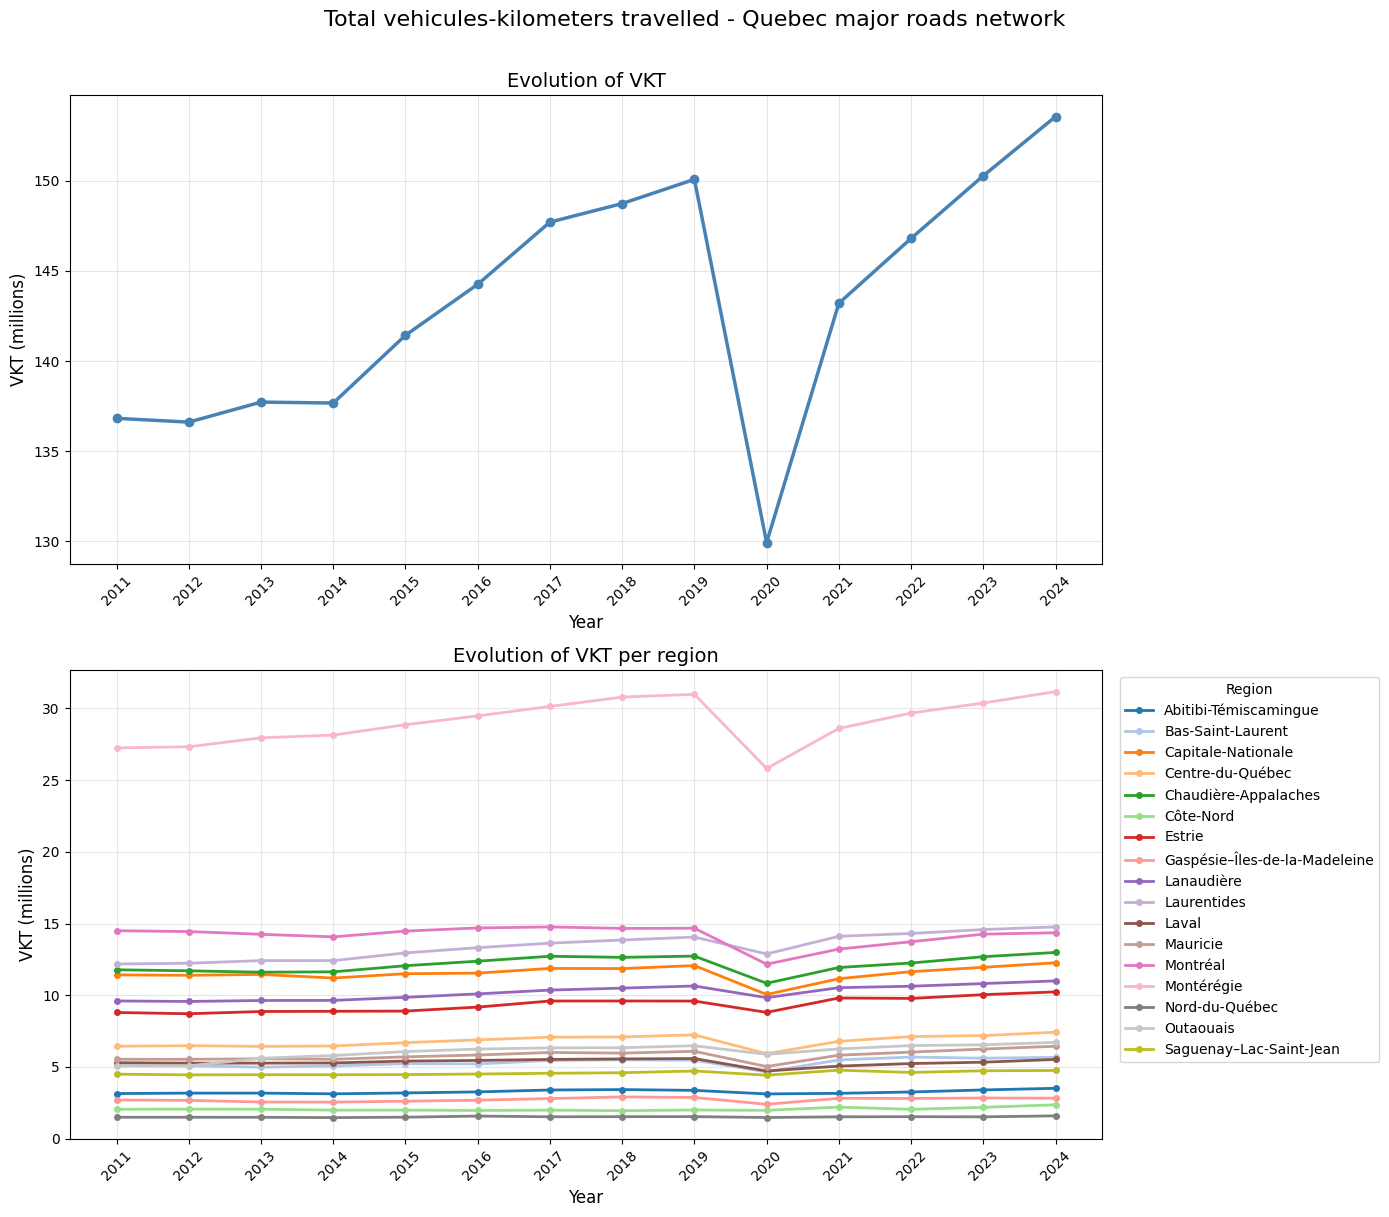

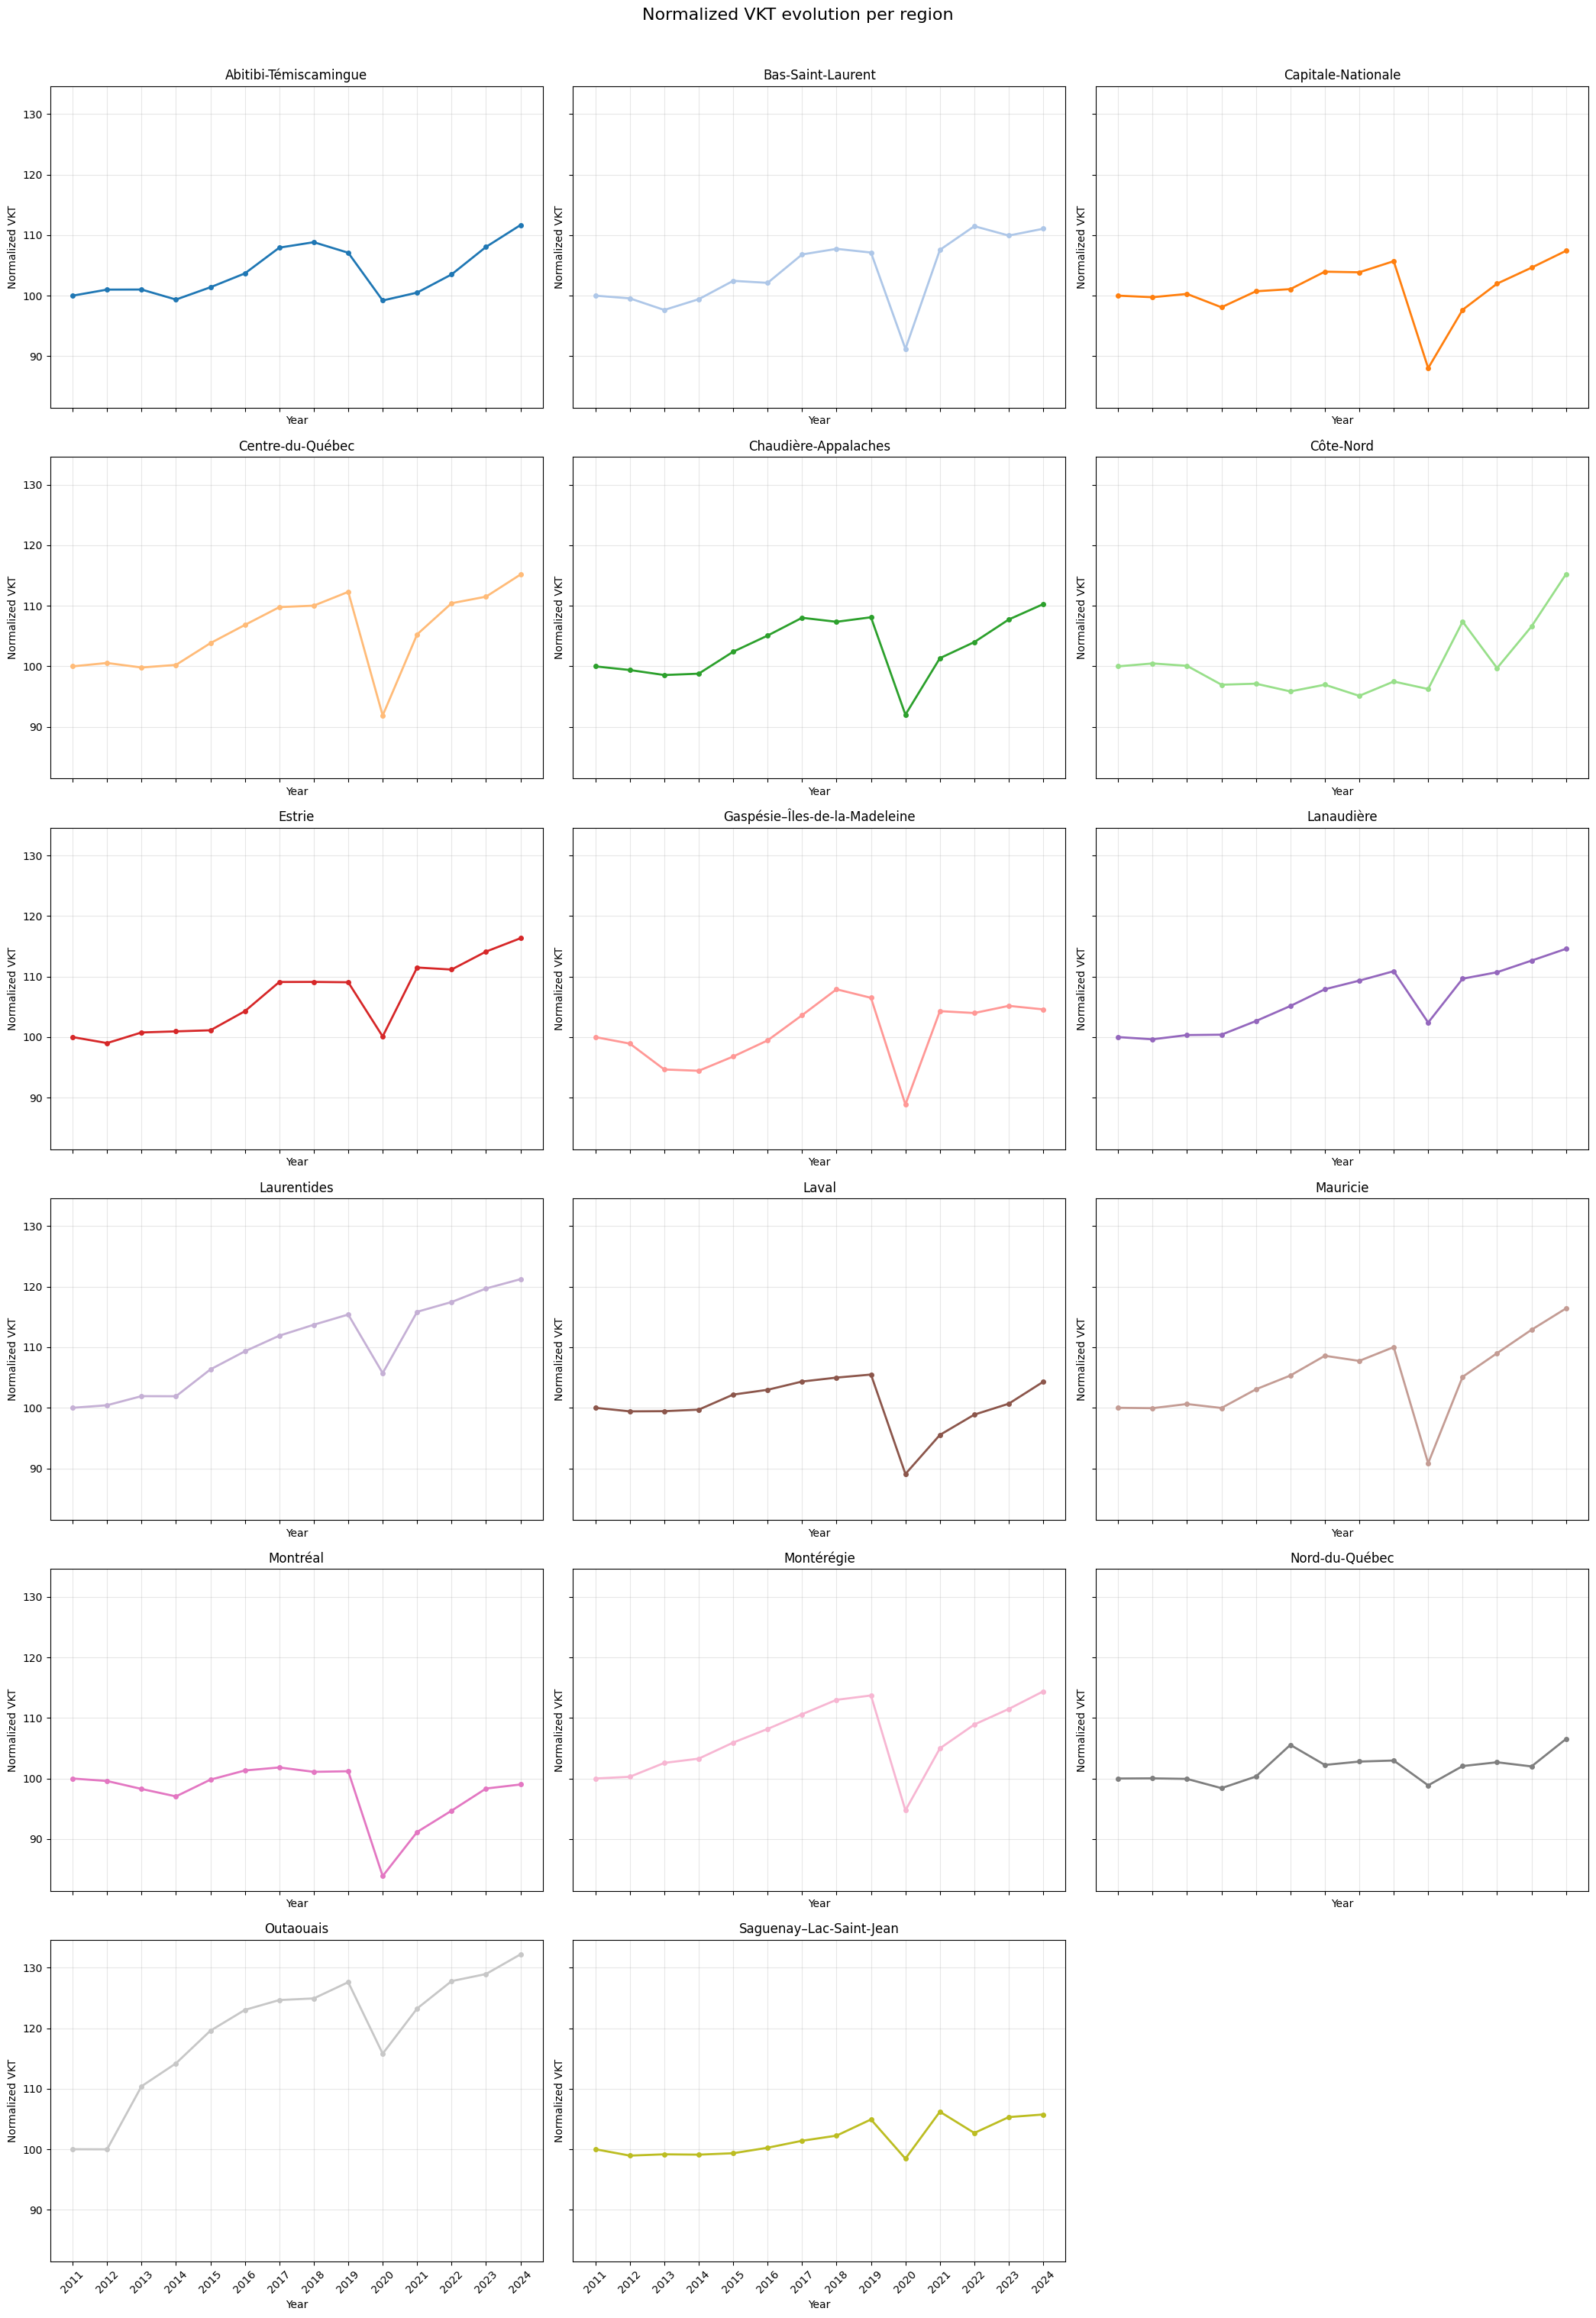

In [639]:
# ── VKT calculation ──────────────────────────────────────────
df_final['VKT'] = df_final['DJMA_working'] * df_final['len'] / 1000  # m to km

vkt_total = df_final.groupby('ANNEE')['VKT'].sum() / 1e6  # millions

# Per year and region
vkt_region = df_final.groupby(['ANNEE', 'region'])['VKT'].sum() / 1e6
vkt_region = vkt_region.reset_index()
regions = sorted(df_final['region'].unique())

# Normalized vkt to compare the trends
base_year = min(years)
vkt_base = vkt_region[vkt_region['ANNEE'] == base_year][['region', 'VKT']].rename(columns={'VKT': 'VKT_base'})
vkt_region = pd.merge(vkt_region, vkt_base, on='region', how='left')
vkt_region['VKT_normalized'] = vkt_region['VKT'] / vkt_region['VKT_base'] * 100

# ── Colors ──────────────────────────────────────────────────────────────────
colors = plt.cm.tab20.colors[:len(regions)]
region_color = dict(zip(regions, colors))

years = sorted(df_final['ANNEE'].unique())

# ── Figure 1: total + per region ─────────────────────────────────────────────
fig1, axes = plt.subplots(2, 1, figsize=(14, 12))

# Subplot 1: total
ax1 = axes[0]
ax1.plot(vkt_total.index, vkt_total.values, color='steelblue', linewidth=2.5, marker='o')
ax1.set_title('Evolution of VKT', fontsize=14)
ax1.set_ylabel('VKT (millions)', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_xticks(years)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(True, alpha=0.3)

# Subplot 2: per region
ax2 = axes[1]
for region in regions:
    data  = vkt_region[vkt_region['region'] == region]
    ax2.plot(data['ANNEE'], data['VKT'],
             color=region_color[region], linewidth=2, marker='o', markersize=4,
             label=f'{region}')

ax2.set_title('Evolution of VKT per region', fontsize=14)
ax2.set_ylabel('VKT (millions)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_xticks(years)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(True, alpha=0.3)
ax2.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

fig1.suptitle('Total vehicules-kilometers travelled - Quebec major roads network', fontsize=16, y=1.01)
fig1.tight_layout()
plt.show()

# ── Figure 2: one subplot per region (normalized VKT) ──────────────────────────────────────────
n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows),
                            sharex=True, sharey=True)
axes2 = np.array(axes2).flatten()

for i, region in enumerate(regions):
    ax = axes2[i]
    data  = vkt_region[vkt_region['region'] == region]
    n_sec = n_sections_region.get(region, 0)

    ax.plot(data['ANNEE'], data['VKT_normalized'],
            color=region_color[region], linewidth=2, marker='o', markersize=4)
    ax.set_title(f'{region}', fontsize=12)
    ax.set_ylabel('Normalized VKT', fontsize=10)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(regions), len(axes2)):
    axes2[j].axis('off')

fig2.suptitle('Normalized VKT evolution per region', fontsize=16, y=1.01)
fig2.tight_layout()
plt.show()